In [ ]:
import numpy as np
spectral_folder_path = '/media/2tbdisk2/data/Haidee_apple_data/Haidee/Data_outputs_NZ2023/Spectral/'


# test_img = np.load(f"{spectral_folder_path}UK2024/50px_{file_name}.npy")

test_img = np.load(f"{spectral_folder_path}subsetted_aggregated_hyperspectral_images/NZ2023/20px_Braeburn_1655_1647.npy")


print(test_img.shape)
print(test_img.min())
print(test_img.max())

(20, 20, 204)
0.011766172
1.7790811


In [ ]:
import numpy as np
spectral_folder_path = '/media/2tbdisk2/data/Haidee_apple_data/Haidee/Data_outputs_NZ2023/Spectral/'


# test_img = np.load(f"{spectral_folder_path}UK2024/50px_{file_name}.npy")

test_img = np.load(f"{spectral_folder_path}subsetted_aggregated_hyperspectral_images/NZ2023/20px_Braeburn_1655_1647.npy")


print(test_img.shape)
print(test_img.min())
print(test_img.max())

(20, 20, 204)
0.011766172
1.7790811


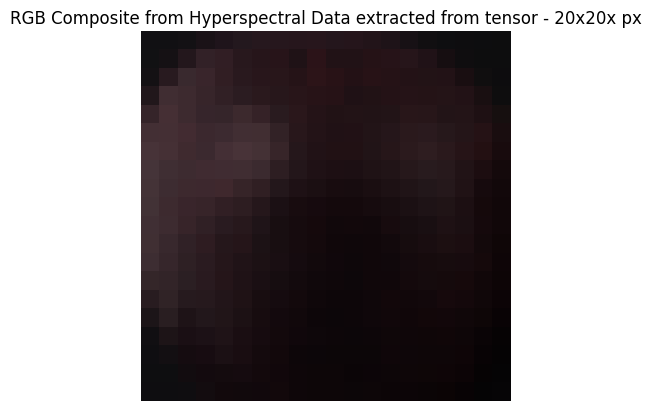

In [ ]:
import matplotlib.pyplot as plt

red_band = test_img[:, :, 69]
green_band = test_img[:, :, 52]
blue_band = test_img[:, :, 18]
rgb_image = np.stack([red_band, green_band, blue_band], axis=-1)
# Display image
plt.imshow(rgb_image)
plt.axis("off")
plt.title("RGB Composite from Hyperspectral Data extracted from tensor - 20x20x px")
plt.show()



In [ ]:
# Get pixel values of black pixels



height, width, _ = rgb_image.shape

# Get pixel values from corners
top_left = rgb_image[0, 0]
top_right = rgb_image[0, width - 1]
bottom_left = rgb_image[height - 1, 0]
bottom_right = rgb_image[height - 1, width - 1]

print("Top-left:", top_left)
print("Top-right:", top_right)
print("Bottom-left:", bottom_left)
print("Bottom-right:", bottom_right)



center_y = height // 2
center_x = width // 2

# Get the pixel value at the center
center_pixel = rgb_image[center_y, center_x]

print("Center pixel value:", center_pixel)



Top-left: [0.0681352  0.06644083 0.07514069]
Top-right: [0.05381243 0.05239385 0.05757986]
Bottom-left: [0.05636627 0.05379477 0.06314507]
Bottom-right: [0.02383086 0.02280002 0.02733254]
Center pixel value: [0.0678358  0.03205119 0.04423042]


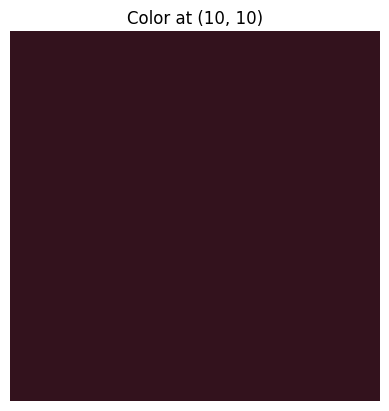

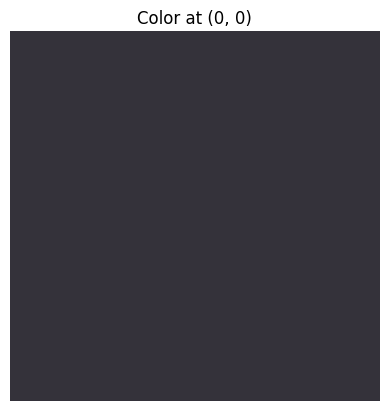

[0.20361471 0.07294717 0.11741964]
[0.20470798 0.19852097 0.23028852]


In [ ]:
#Display the color as a swatch
# Create a 1x1 image with the pixel color


rgb_image_normalized = (rgb_image - rgb_image.min()) / (rgb_image.max() - rgb_image.min())


x, y = 10, 10

pixel_color = rgb_image_normalized[x, y]
color_patch = np.array([[pixel_color]])

# Display the color
plt.imshow(color_patch)
plt.axis("off")
plt.title(f"Color at ({x}, {y})")
plt.show()

x, y = 0, 0

pixel_color = rgb_image_normalized[x, y]
color_patch = np.array([[pixel_color]])

# Display the color
plt.imshow(color_patch)
plt.axis("off")
plt.title(f"Color at ({x}, {y})")
plt.show()

print(rgb_image_normalized[10, 10])
print(rgb_image_normalized[0, 0])

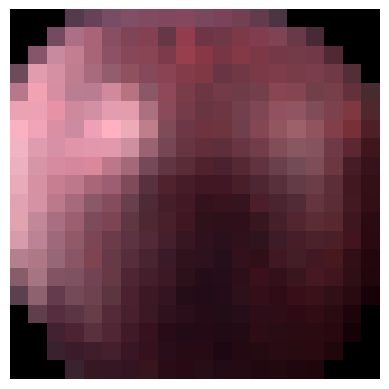

In [ ]:
import numpy as np


color_variation = rgb_image_normalized.std(axis=-1)

# Define a threshold for colorfulness (tune this value)
threshold = 0.03

# Create a mask for colorful pixels (exclude greyish ones)
colorful_mask = color_variation > threshold

# Option 1: Get only colorful pixel values
colorful_pixels = rgb_image_normalized[colorful_mask]

# Option 2: Create a new image with grey pixels removed (set to black)
filtered_image = np.zeros_like(rgb_image_normalized)
filtered_image[colorful_mask] = rgb_image_normalized[colorful_mask]

plt.imshow(filtered_image)
plt.axis("off")
plt.show()


In [ ]:
print(filtered_image[10,10])

[0.20361471 0.07294717 0.11741964]


In [ ]:
# import numpy as np
# import matplotlib.pyplot as plt

# # Using colour to filter out greyish pixels
# def load_and_filter_image(file_path, threshold=0.03):
#     # Load the hyperspectral image
#     test_img = np.load(file_path)
    
#     # Extract RGB bands
#     red_band = test_img[:, :, 69]
#     green_band = test_img[:, :, 52]
#     blue_band = test_img[:, :, 18]
#     rgb_image = np.stack([red_band, green_band, blue_band], axis=-1)
    
    
#     # Normalize the image to 0–1 range
#     rgb_image_normalized = (rgb_image - rgb_image.min()) / (rgb_image.max() - rgb_image.min())
    
#     # Calculate the standard deviation across the RGB channels for each pixel
#     color_variation = rgb_image_normalized.std(axis=-1)
    
#     # Create a mask for colorful pixels (exclude greyish ones)
#     colorful_mask = color_variation > threshold
    
#     # Create a new image with grey pixels removed (set to black)
#     # filtered_image = np.zeros_like(rgb_image_normalized) # black background
#     filtered_image = np.ones_like(rgb_image_normalized)  # white background
#     filtered_image[colorful_mask] = rgb_image_normalized[colorful_mask]
    


#     fig, axes = plt.subplots(1, 2, figsize=(10, 5))
#     axes[0].imshow(rgb_image_normalized)
#     axes[0].axis("off")
#     axes[0].set_title("Original Image")
     
#     axes[1].imshow(filtered_image)
#     axes[1].axis("off")
#     axes[1].set_title("Filtered Image")
    
#     plt.tight_layout()
#     plt.show()



In [ ]:
import numpy as np
import matplotlib.pyplot as plt

# Using the waebands betweeen 450-650 nm where background is typically flat to exclude pixels
def load_and_filter_image(file_path, threshold=0.03):
    # Load the hyperspectral image
    test_img = np.load(file_path)
    
    band_indices = list(range(19, 86)) # bands between 450-650nm (actually '452.25' to '648.95')

    spectral_bands = test_img[:, :, band_indices]
    
    # calculate the standard deviation across the spectral bands for each pixel
    std_dev = spectral_bands.std(axis=-1)
    
    # Create a mask for low variation (flat spectra)
    flat_mask = std_dev < threshold
    
    # Create a new image with grey pixels removed (set to black)
    # filtered_image = np.zeros_like(rgb_image_normalized) # black background
    
    filtered_cube = np.ones_like(test_img) # white background
    for b in range(test_img.shape[2]):
        band = test_img[:, :, b]
        band_filtered = np.ones_like(band)
        band_filtered[~flat_mask] = band[~flat_mask]
        filtered_cube[:, :, b] = band_filtered

    # Extract RGB bands from the filtered cube
    red_band = filtered_cube[:, :, 69]
    green_band = filtered_cube[:, :, 52]
    blue_band = filtered_cube[:, :, 18]
    rgb_image = np.stack([red_band, green_band, blue_band], axis=-1)

    red_band2 = test_img[:, :, 69]
    green_band2 = test_img[:, :, 52]
    blue_band2 = test_img[:, :, 18]
    rgb_image2 = np.stack([red_band2, green_band2, blue_band2], axis=-1)

    # Normalize the image to 0–1 range
    test_img_normalized = (rgb_image2 - rgb_image2.min()) / (rgb_image2.max() - rgb_image2.min())
    rgb_image_normalized = (rgb_image - rgb_image.min()) / (rgb_image.max() - rgb_image.min())

    # Display the original and filtered images side by side
    fig, axes = plt.subplots(1, 2, figsize=(10, 5))
    axes[0].imshow(test_img_normalized)
    axes[0].axis("off")
    axes[0].set_title("Original Image")

    axes[1].imshow(rgb_image_normalized)
    axes[1].axis("off")
    axes[1].set_title("Filtered Image")

    plt.tight_layout()
    plt.show()




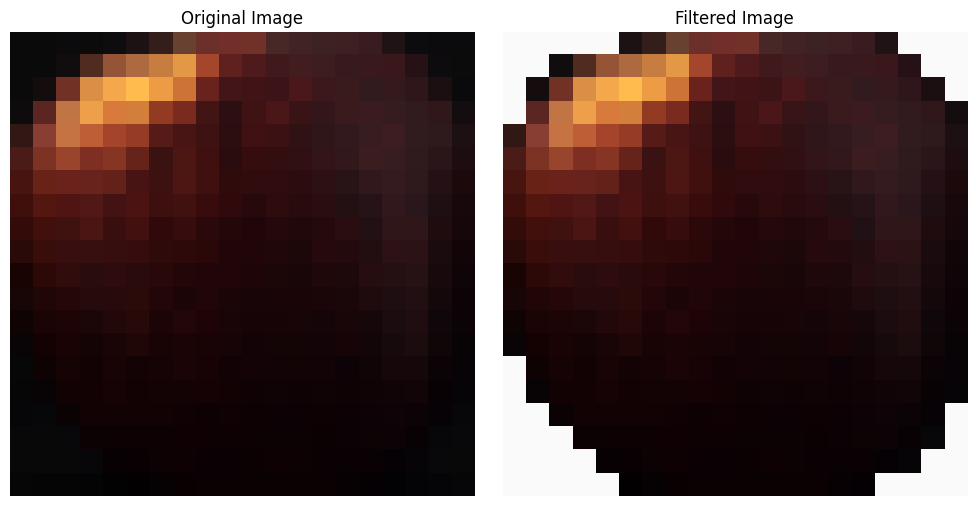

In [ ]:

load_and_filter_image('/media/2tbdisk2/data/Haidee_apple_data/Haidee/Data_outputs_NZ2023/Spectral/subsetted_aggregated_hyperspectral_images/NZ2023/20px_Gala_1432_3118.npy', threshold=0.010)

In [ ]:
import pandas as pd
pickle_path = '/home/ht21074/Auto_box_apples/Auto_box_apples/Source_folder/Pickle_files/'


files_NZ2023_a =  pd.read_pickle(f'{pickle_path}aggregated_files_NZ2023_a.pkl')

files_NZ2024_a =  pd.read_pickle(f'{pickle_path}aggregated_files_NZ2024_a.pkl')

files_UK2024_a =  pd.read_pickle(f'{pickle_path}aggregated_files_UK2024_a.pkl')

print(len(files_NZ2023_a))
print(len(files_NZ2024_a))
print(len(files_UK2024_a))

print(files_NZ2023_a[:3])


1693
1340
2472
                                      Image_folder_A    image_filename_A  \
0  20230328 Fuji PFR orchard early pick/2023-03-2...  2023-03-28_002.png   
0  20230328 Fuji PFR orchard early pick/2023-03-2...  2023-03-28_002.png   
0  20230328 Fuji PFR orchard early pick/2023-03-2...  2023-03-28_002.png   

       ID  Number  Firmness1  Firmness2   Brix  Starch  Starch2    Streif  \
0  Fuji_1     1.0       6.38       6.23  12.43    50.0      8.0  4.057924   
0  Fuji_1     1.0       6.38       6.23  12.43    50.0      8.0  4.057924   
0  Fuji_1     1.0       6.38       6.23  12.43    50.0      8.0  4.057924   

   Avg_firmness Cultivar                                      sorted_tensor  \
0         6.305     Fuji  [[tensor(29.8971), tensor(121.5800), tensor(16...   
0         6.305     Fuji  [[tensor(29.8971), tensor(121.5800), tensor(16...   
0         6.305     Fuji  [[tensor(29.8971), tensor(121.5800), tensor(16...   

   number_of_apples  Count                            

In [ ]:
# Take a random duplicated index (select random apple from each image so position will not affect the filtering result)

# shuffle order
files_NZ2023_a_shuffled = files_NZ2023_a.sample(frac=1, random_state=123)
files_NZ2024_a_shuffled = files_NZ2024_a.sample(frac=1, random_state=123)
files_UK2024_a_shuffled = files_UK2024_a.sample(frac=1, random_state=123)

# Drop duplicates, keeping the first (which is now random due to shuffling)
files_NZ2023_a_rand_sample = files_NZ2023_a_shuffled[~files_NZ2023_a_shuffled.index.duplicated(keep='first')]
files_NZ2024_a_rand_sample = files_NZ2024_a_shuffled[~files_NZ2024_a_shuffled.index.duplicated(keep='first')]
files_UK2024_a_rand_sample = files_UK2024_a_shuffled[~files_UK2024_a_shuffled.index.duplicated(keep='first')]


In [ ]:
# Samples 20 from each cultivar or all the samples if less than 20
def sample_groups(df, sample_size):
    return df.groupby('Cultivar').apply(
        lambda x: x.sample(min(len(x), sample_size), replace=False)
    ).reset_index(drop=True)


In [ ]:
data_NZ2023_rand_selection = sample_groups(files_NZ2023_a_rand_sample, 5)
data_NZ2024_rand_selection = sample_groups(files_NZ2024_a_rand_sample, 5)
data_UK2024_rand_selection = sample_groups(files_UK2024_a_rand_sample, 5)

# for spectral .npy files
# data_NZ2023_rand_selection['image_path'] = '/media/2tbdisk2/data/Haidee_apple_data/Haidee/Data_outputs_NZ2023/Spectral/subsetted_aggregated_hyperspectral_images/NZ2023/' + '20px_' + data_NZ2023_rand_selection["img_ID"] + '.npy'
# data_NZ2024_rand_selection['image_path'] = '/media/2tbdisk2/data/Haidee_apple_data/Haidee/Data_outputs_NZ2023/Spectral/subsetted_aggregated_hyperspectral_images/NZ2024/' + '20px_' + data_NZ2024_rand_selection["img_ID"] + '.npy'
# data_UK2024_rand_selection['image_path'] = '/media/2tbdisk2/data/Haidee_apple_data/Haidee/Data_outputs_NZ2023/Spectral/subsetted_aggregated_hyperspectral_images/UK2024/' + '20px_' + data_UK2024_rand_selection["img_ID"] + '.npy'

# for png files
data_NZ2023_rand_selection['image_path'] = '/media/2tbdisk2/data/Haidee_apple_data/Haidee/Hyperspectral_images/spectral_NZ_2023/' + data_NZ2023_rand_selection["Image_folder_A"] 
data_NZ2024_rand_selection['image_path'] = '/media/2tbdisk2/data/Haidee_apple_data/Haidee/Hyperspectral_images/spectral_NZ_2024/' + data_NZ2024_rand_selection["Image_folder_A"] 
data_UK2024_rand_selection['image_path'] = '/media/2tbdisk2/data/Haidee_apple_data/Haidee/Hyperspectral_images/spectral_UK_2024/' + data_UK2024_rand_selection["Image_folder_A"] 


data_joined = pd.concat([data_NZ2023_rand_selection, data_NZ2024_rand_selection, data_UK2024_rand_selection]).reset_index(drop=True)

/tmp/ipykernel_4135111/3186019314.py:3: DeprecationWarning: DataFrameGroupBy.apply operated on the grouping columns. This behavior is deprecated, and in a future version of pandas the grouping columns will be excluded from the operation. Either pass `include_groups=False` to exclude the groupings or explicitly select the grouping columns after groupby to silence this warning.
  return df.groupby('Cultivar').apply(
/tmp/ipykernel_4135111/3186019314.py:3: DeprecationWarning: DataFrameGroupBy.apply operated on the grouping columns. This behavior is deprecated, and in a future version of pandas the grouping columns will be excluded from the operation. Either pass `include_groups=False` to exclude the groupings or explicitly select the grouping columns after groupby to silence this warning.
  return df.groupby('Cultivar').apply(
/tmp/ipykernel_4135111/3186019314.py:3: DeprecationWarning: DataFrameGroupBy.apply operated on the grouping columns. This behavior is deprecated, and in a future ve

In [ ]:
print(data_joined)
print(data_joined['image_path'].iloc[0])

                                       Image_folder_A    image_filename_A  \
0   20230404 Braeburn TG/2023-04-04_009/2023-04-04...  2023-04-04_009.png   
1   20230404 Braeburn TG/2023-04-04_013/2023-04-04...  2023-04-04_013.png   
2   20230404 Braeburn TG/2023-04-04_021/2023-04-04...  2023-04-04_021.png   
3   20230404 Braeburn TG/2023-04-04_033/2023-04-04...  2023-04-04_033.png   
4   20230404 Braeburn TG/2023-04-04_005/2023-04-04...  2023-04-04_005.png   
..                                                ...                 ...   
68                       20241023GDFuji/1495/1495.png            1495.png   
69                 20241007GalaGDBraeburn/837/837.png             837.png   
70                  20240918CoxJazzGalaBB/249/249.png             249.png   
71                  20240918CoxJazzGalaBB/257/257.png             257.png   
72                  20240918CoxJazzGalaBB/253/253.png             253.png   

                       ID  Number  Firmness1  Firmness2   Brix  Starch  \
0

In [ ]:
for index, row in data_joined.iterrows():
    load_and_filter_image(row['image_path'], threshold=0.02)
    print(f"Processed image {index + 1}/{len(data_joined)}: {row['image_path']}")

In [ ]:
import cv
import numpy as np
import matplotlib.pyplot as plt

def extract_largest_inner_rectangle(image):
    """
    Detects an apple in the image (on black background), fits an ellipse, and extracts
    the largest axis-aligned rectangle fully inside the apple.

    Args:
        image: RGB image as a NumPy array.

    Returns:
        cropped_rect: Cropped image containing the largest inner rectangle.
        rect_coords: Coordinates (x, y, w, h) of the rectangle in the original image.
    """
    # Convert to grayscale and threshold to get the apple mask
    gray = cv.cvtColor(image, cv.COLOR_RGB2GRAY)
    _, thresh = cv.threshold(gray, 10, 255, cv.THRESH_BINARY)

    # Find contours of the apple
    contours, _ = cv.findContours(thresh, cv.RETR_EXTERNAL, cv.CHAIN_APPROX_SIMPLE)
    if not contours:
        raise ValueError("No object found in the image.")

    # Fit an ellipse to the largest contour
    contour = max(contours, key=cv.contourArea)
    if len(contour) < 5:
        raise ValueError("Not enough points to fit an ellipse.")

    ellipse = cv.fitEllipse(contour)
    (cx, cy), (major_axis, minor_axis), angle = ellipse

    # Largest rectangle inside ellipse (assuming axis-aligned)
    w = major_axis / np.sqrt(2)
    h = minor_axis / np.sqrt(2)

    x1 = int(cx - w / 2)
    y1 = int(cy - h / 2)
    x2 = int(cx + w / 2)
    y2 = int(cy + h / 2)

    # Ensure rectangle stays within image bounds
    x1 = max(0, x1)
    y1 = max(0, y1)
    x2 = min(image.shape[1], x2)
    y2 = min(image.shape[0], y2)

    # Crop the rectangle
    cropped_rect = image[y1:y2, x1:x2]
    rect_coords = (x1, y1, x2 - x1, y2 - y1)

    return cropped_rect, rect_coords


In [ ]:
import matplotlib.pyplot as plt

red_band = test_img[:, :, 69]
green_band = test_img[:, :, 52]
blue_band = test_img[:, :, 18]
rgb_image = np.stack([red_band, green_band, blue_band], axis=-1)
# Display image
plt.imshow(rgb_image)
plt.axis("off")
plt.title("RGB Composite from Hyperspectral Data extracted from tensor - 20x20x px")
plt.show()



In [ ]:
# Get pixel values of black pixels



height, width, _ = rgb_image.shape

# Get pixel values from corners
top_left = rgb_image[0, 0]
top_right = rgb_image[0, width - 1]
bottom_left = rgb_image[height - 1, 0]
bottom_right = rgb_image[height - 1, width - 1]

print("Top-left:", top_left)
print("Top-right:", top_right)
print("Bottom-left:", bottom_left)
print("Bottom-right:", bottom_right)



center_y = height // 2
center_x = width // 2

# Get the pixel value at the center
center_pixel = rgb_image[center_y, center_x]

print("Center pixel value:", center_pixel)



Top-left: [0.0681352  0.06644083 0.07514069]
Top-right: [0.05381243 0.05239385 0.05757986]
Bottom-left: [0.05636627 0.05379477 0.06314507]
Bottom-right: [0.02383086 0.02280002 0.02733254]
Center pixel value: [0.0678358  0.03205119 0.04423042]


In [ ]:
#Display the color as a swatch
# Create a 1x1 image with the pixel color


rgb_image_normalized = (rgb_image - rgb_image.min()) / (rgb_image.max() - rgb_image.min())


x, y = 10, 10

pixel_color = rgb_image_normalized[x, y]
color_patch = np.array([[pixel_color]])

# Display the color
plt.imshow(color_patch)
plt.axis("off")
plt.title(f"Color at ({x}, {y})")
plt.show()

x, y = 0, 0

pixel_color = rgb_image_normalized[x, y]
color_patch = np.array([[pixel_color]])

# Display the color
plt.imshow(color_patch)
plt.axis("off")
plt.title(f"Color at ({x}, {y})")
plt.show()

print(rgb_image_normalized[10, 10])
print(rgb_image_normalized[0, 0])

In [ ]:
import numpy as np


color_variation = rgb_image_normalized.std(axis=-1)

# Define a threshold for colorfulness (tune this value)
threshold = 0.03

# Create a mask for colorful pixels (exclude greyish ones)
colorful_mask = color_variation > threshold

# Option 1: Get only colorful pixel values
colorful_pixels = rgb_image_normalized[colorful_mask]

# Option 2: Create a new image with grey pixels removed (set to black)
filtered_image = np.zeros_like(rgb_image_normalized)
filtered_image[colorful_mask] = rgb_image_normalized[colorful_mask]

plt.imshow(filtered_image)
plt.axis("off")
plt.show()


In [ ]:
print(filtered_image[10,10])

[0.20361471 0.07294717 0.11741964]


In [ ]:
# import numpy as np
# import matplotlib.pyplot as plt

# # Using colour to filter out greyish pixels
# def load_and_filter_image(file_path, threshold=0.03):
#     # Load the hyperspectral image
#     test_img = np.load(file_path)
    
#     # Extract RGB bands
#     red_band = test_img[:, :, 69]
#     green_band = test_img[:, :, 52]
#     blue_band = test_img[:, :, 18]
#     rgb_image = np.stack([red_band, green_band, blue_band], axis=-1)
    
    
#     # Normalize the image to 0–1 range
#     rgb_image_normalized = (rgb_image - rgb_image.min()) / (rgb_image.max() - rgb_image.min())
    
#     # Calculate the standard deviation across the RGB channels for each pixel
#     color_variation = rgb_image_normalized.std(axis=-1)
    
#     # Create a mask for colorful pixels (exclude greyish ones)
#     colorful_mask = color_variation > threshold
    
#     # Create a new image with grey pixels removed (set to black)
#     # filtered_image = np.zeros_like(rgb_image_normalized) # black background
#     filtered_image = np.ones_like(rgb_image_normalized)  # white background
#     filtered_image[colorful_mask] = rgb_image_normalized[colorful_mask]
    


#     fig, axes = plt.subplots(1, 2, figsize=(10, 5))
#     axes[0].imshow(rgb_image_normalized)
#     axes[0].axis("off")
#     axes[0].set_title("Original Image")
     
#     axes[1].imshow(filtered_image)
#     axes[1].axis("off")
#     axes[1].set_title("Filtered Image")
    
#     plt.tight_layout()
#     plt.show()



In [ ]:
import numpy as np
import matplotlib.pyplot as plt

# Using the waebands betweeen 450-650 nm where background is typically flat to exclude pixels
def load_and_filter_image(file_path, threshold=0.03):
    # Load the hyperspectral image
    test_img = np.load(file_path)
    
    band_indices = list(range(19, 86)) # bands between 450-650nm (actually '452.25' to '648.95')

    spectral_bands = test_img[:, :, band_indices]
    
    # calculate the standard deviation across the spectral bands for each pixel
    std_dev = spectral_bands.std(axis=-1)
    
    # Create a mask for low variation (flat spectra)
    flat_mask = std_dev < threshold
    
    # Create a new image with grey pixels removed (set to black)
    # filtered_image = np.zeros_like(rgb_image_normalized) # black background
    
    filtered_cube = np.ones_like(test_img) # white background
    for b in range(test_img.shape[2]):
        band = test_img[:, :, b]
        band_filtered = np.ones_like(band)
        band_filtered[~flat_mask] = band[~flat_mask]
        filtered_cube[:, :, b] = band_filtered

    # Extract RGB bands from the filtered cube
    red_band = filtered_cube[:, :, 69]
    green_band = filtered_cube[:, :, 52]
    blue_band = filtered_cube[:, :, 18]
    rgb_image = np.stack([red_band, green_band, blue_band], axis=-1)

    red_band2 = test_img[:, :, 69]
    green_band2 = test_img[:, :, 52]
    blue_band2 = test_img[:, :, 18]
    rgb_image2 = np.stack([red_band2, green_band2, blue_band2], axis=-1)

    # Normalize the image to 0–1 range
    test_img_normalized = (rgb_image2 - rgb_image2.min()) / (rgb_image2.max() - rgb_image2.min())
    rgb_image_normalized = (rgb_image - rgb_image.min()) / (rgb_image.max() - rgb_image.min())

    # Display the original and filtered images side by side
    fig, axes = plt.subplots(1, 2, figsize=(10, 5))
    axes[0].imshow(test_img_normalized)
    axes[0].axis("off")
    axes[0].set_title("Original Image")

    axes[1].imshow(rgb_image_normalized)
    axes[1].axis("off")
    axes[1].set_title("Filtered Image")

    plt.tight_layout()
    plt.show()




In [ ]:

load_and_filter_image('/media/2tbdisk2/data/Haidee_apple_data/Haidee/Data_outputs_NZ2023/Spectral/subsetted_aggregated_hyperspectral_images/NZ2023/20px_Gala_1432_3118.npy', threshold=0.010)

In [ ]:
import pandas as pd
pickle_path = '/home/ht21074/Auto_box_apples/Auto_box_apples/Source_folder/Pickle_files/'


files_NZ2023_a =  pd.read_pickle(f'{pickle_path}aggregated_files_NZ2023_a.pkl')

files_NZ2024_a =  pd.read_pickle(f'{pickle_path}aggregated_files_NZ2024_a.pkl')

files_UK2024_a =  pd.read_pickle(f'{pickle_path}aggregated_files_UK2024_a.pkl')

print(len(files_NZ2023_a))
print(len(files_NZ2024_a))
print(len(files_UK2024_a))

print(files_NZ2023_a[:3])


1693
1340
2472
                                      Image_folder_A    image_filename_A  \
0  20230328 Fuji PFR orchard early pick/2023-03-2...  2023-03-28_002.png   
0  20230328 Fuji PFR orchard early pick/2023-03-2...  2023-03-28_002.png   
0  20230328 Fuji PFR orchard early pick/2023-03-2...  2023-03-28_002.png   

       ID  Number  Firmness1  Firmness2   Brix  Starch  Starch2    Streif  \
0  Fuji_1     1.0       6.38       6.23  12.43    50.0      8.0  4.057924   
0  Fuji_1     1.0       6.38       6.23  12.43    50.0      8.0  4.057924   
0  Fuji_1     1.0       6.38       6.23  12.43    50.0      8.0  4.057924   

   Avg_firmness Cultivar                                      sorted_tensor  \
0         6.305     Fuji  [[tensor(29.8971), tensor(121.5800), tensor(16...   
0         6.305     Fuji  [[tensor(29.8971), tensor(121.5800), tensor(16...   
0         6.305     Fuji  [[tensor(29.8971), tensor(121.5800), tensor(16...   

   number_of_apples  Count                            

In [ ]:
# Take a random duplicated index (select random apple from each image so position will not affect the filtering result)

# shuffle order
files_NZ2023_a_shuffled = files_NZ2023_a.sample(frac=1, random_state=123)
files_NZ2024_a_shuffled = files_NZ2024_a.sample(frac=1, random_state=123)
files_UK2024_a_shuffled = files_UK2024_a.sample(frac=1, random_state=123)

# Drop duplicates, keeping the first (which is now random due to shuffling)
files_NZ2023_a_rand_sample = files_NZ2023_a_shuffled[~files_NZ2023_a_shuffled.index.duplicated(keep='first')]
files_NZ2024_a_rand_sample = files_NZ2024_a_shuffled[~files_NZ2024_a_shuffled.index.duplicated(keep='first')]
files_UK2024_a_rand_sample = files_UK2024_a_shuffled[~files_UK2024_a_shuffled.index.duplicated(keep='first')]


In [ ]:
# Samples 20 from each cultivar or all the samples if less than 20
def sample_groups(df, sample_size):
    return df.groupby('Cultivar').apply(
        lambda x: x.sample(min(len(x), sample_size), replace=False)
    ).reset_index(drop=True)


In [ ]:
data_NZ2023_rand_selection = sample_groups(files_NZ2023_a_rand_sample, 5)
data_NZ2024_rand_selection = sample_groups(files_NZ2024_a_rand_sample, 5)
data_UK2024_rand_selection = sample_groups(files_UK2024_a_rand_sample, 5)

# for spectral .npy files
# data_NZ2023_rand_selection['image_path'] = '/media/2tbdisk2/data/Haidee_apple_data/Haidee/Data_outputs_NZ2023/Spectral/subsetted_aggregated_hyperspectral_images/NZ2023/' + '20px_' + data_NZ2023_rand_selection["img_ID"] + '.npy'
# data_NZ2024_rand_selection['image_path'] = '/media/2tbdisk2/data/Haidee_apple_data/Haidee/Data_outputs_NZ2023/Spectral/subsetted_aggregated_hyperspectral_images/NZ2024/' + '20px_' + data_NZ2024_rand_selection["img_ID"] + '.npy'
# data_UK2024_rand_selection['image_path'] = '/media/2tbdisk2/data/Haidee_apple_data/Haidee/Data_outputs_NZ2023/Spectral/subsetted_aggregated_hyperspectral_images/UK2024/' + '20px_' + data_UK2024_rand_selection["img_ID"] + '.npy'

# for png files
data_NZ2023_rand_selection['image_path'] = '/media/2tbdisk2/data/Haidee_apple_data/Haidee/Hyperspectral_images/spectral_NZ_2023/' + data_NZ2023_rand_selection["Image_folder_A"] 
data_NZ2024_rand_selection['image_path'] = '/media/2tbdisk2/data/Haidee_apple_data/Haidee/Hyperspectral_images/spectral_NZ_2024/' + data_NZ2024_rand_selection["Image_folder_A"] 
data_UK2024_rand_selection['image_path'] = '/media/2tbdisk2/data/Haidee_apple_data/Haidee/Hyperspectral_images/spectral_UK_2024/' + data_UK2024_rand_selection["Image_folder_A"] 


data_joined = pd.concat([data_NZ2023_rand_selection, data_NZ2024_rand_selection, data_UK2024_rand_selection]).reset_index(drop=True)

/tmp/ipykernel_4135111/3186019314.py:3: DeprecationWarning: DataFrameGroupBy.apply operated on the grouping columns. This behavior is deprecated, and in a future version of pandas the grouping columns will be excluded from the operation. Either pass `include_groups=False` to exclude the groupings or explicitly select the grouping columns after groupby to silence this warning.
  return df.groupby('Cultivar').apply(
/tmp/ipykernel_4135111/3186019314.py:3: DeprecationWarning: DataFrameGroupBy.apply operated on the grouping columns. This behavior is deprecated, and in a future version of pandas the grouping columns will be excluded from the operation. Either pass `include_groups=False` to exclude the groupings or explicitly select the grouping columns after groupby to silence this warning.
  return df.groupby('Cultivar').apply(
/tmp/ipykernel_4135111/3186019314.py:3: DeprecationWarning: DataFrameGroupBy.apply operated on the grouping columns. This behavior is deprecated, and in a future ve

In [ ]:
print(data_joined)
print(data_joined['image_path'].iloc[0])

                                       Image_folder_A    image_filename_A  \
0   20230404 Braeburn TG/2023-04-04_009/2023-04-04...  2023-04-04_009.png   
1   20230404 Braeburn TG/2023-04-04_013/2023-04-04...  2023-04-04_013.png   
2   20230404 Braeburn TG/2023-04-04_021/2023-04-04...  2023-04-04_021.png   
3   20230404 Braeburn TG/2023-04-04_033/2023-04-04...  2023-04-04_033.png   
4   20230404 Braeburn TG/2023-04-04_005/2023-04-04...  2023-04-04_005.png   
..                                                ...                 ...   
68                       20241023GDFuji/1495/1495.png            1495.png   
69                 20241007GalaGDBraeburn/837/837.png             837.png   
70                  20240918CoxJazzGalaBB/249/249.png             249.png   
71                  20240918CoxJazzGalaBB/257/257.png             257.png   
72                  20240918CoxJazzGalaBB/253/253.png             253.png   

                       ID  Number  Firmness1  Firmness2   Brix  Starch  \
0

In [ ]:
for index, row in data_joined.iterrows():
    load_and_filter_image(row['image_path'], threshold=0.02)
    print(f"Processed image {index + 1}/{len(data_joined)}: {row['image_path']}")

In [ ]:
import cv
import numpy as np
import matplotlib.pyplot as plt

def extract_largest_inner_rectangle(image):
    """
    Detects an apple in the image (on black background), fits an ellipse, and extracts
    the largest axis-aligned rectangle fully inside the apple.

    Args:
        image: RGB image as a NumPy array.

    Returns:
        cropped_rect: Cropped image containing the largest inner rectangle.
        rect_coords: Coordinates (x, y, w, h) of the rectangle in the original image.
    """
    # Convert to grayscale and threshold to get the apple mask
    gray = cv.cvtColor(image, cv.COLOR_RGB2GRAY)
    _, thresh = cv.threshold(gray, 10, 255, cv.THRESH_BINARY)

    # Find contours of the apple
    contours, _ = cv.findContours(thresh, cv.RETR_EXTERNAL, cv.CHAIN_APPROX_SIMPLE)
    if not contours:
        raise ValueError("No object found in the image.")

    # Fit an ellipse to the largest contour
    contour = max(contours, key=cv.contourArea)
    if len(contour) < 5:
        raise ValueError("Not enough points to fit an ellipse.")

    ellipse = cv.fitEllipse(contour)
    (cx, cy), (major_axis, minor_axis), angle = ellipse

    # Largest rectangle inside ellipse (assuming axis-aligned)
    w = major_axis / np.sqrt(2)
    h = minor_axis / np.sqrt(2)

    x1 = int(cx - w / 2)
    y1 = int(cy - h / 2)
    x2 = int(cx + w / 2)
    y2 = int(cy + h / 2)

    # Ensure rectangle stays within image bounds
    x1 = max(0, x1)
    y1 = max(0, y1)
    x2 = min(image.shape[1], x2)
    y2 = min(image.shape[0], y2)

    # Crop the rectangle
    cropped_rect = image[y1:y2, x1:x2]
    rect_coords = (x1, y1, x2 - x1, y2 - y1)

    return cropped_rect, rect_coords
